# Dueling Contextual Bandit for Fair Model Initialization

This notebook learns fair initialization scores for all 20 LLM models from pairwise comparison data.

Instead of simple aggregation (which biases by matchup frequency), dueling bandits learn context-aware quality weights that account for opponent strength.

**Dataset**: df_bandit.json (25,322 records, all 20 models)

## 1. Import Required Libraries

In [190]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
import os

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully")

All libraries imported successfully


## 2. Load and Explore the Dataset

In [191]:
# Load df_bandit.json dataset (using new version with all 20 models)
print("Loading df_bandit.json...")
df = pd.read_json('data/df_bandit.json', lines=True)

print(f"Dataset loaded: {len(df)} records")
print(f"\nDataset Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())

Loading df_bandit.json...
Dataset loaded: 25322 records

Dataset Shape: (25322, 24)

Columns (24):
['question_id', 'model_a', 'model_b', 'winner', 'judge', 'conversation_a', 'conversation_b', 'turn', 'language', 'tstamp', 'toxic_either', 'prompt_text', 'prompt_length', 'difficulty_score', 'is_easy', 'is_medium_difficulty', 'is_hard', 'is_short', 'is_medium_len', 'is_long', 'is_analytical', 'is_informational', 'is_creative', 'is_other']


In [192]:
# Display first few rows
print("First 3 rows:")
df.head(3)

First 3 rows:


,question_id,model_a,model_b,winner,judge,conversation_a,conversation_b,turn,language,tstamp,...,is_easy,is_medium_difficulty,is_hard,is_short,is_medium_len,is_long,is_analytical,is_informational,is_creative,is_other
0,58210e39b3fd4441a2bd4a518bb44c2d,chatglm-6b,koala-13b,model_b,arena_user_973,[{'content': 'What is the difference between O...,[{'content': 'What is the difference between O...,1,English,1.682352e+09,...,0,1,0,1,0,0,0,1,0,0
1,2564acd09e3942fd97657d05282d4389,oasst-pythia-12b,alpaca-13b,tie,arena_user_973,[{'content': 'Why did my parent not invite me ...,[{'content': 'Why did my parent not invite me ...,1,English,1.682352e+09,...,1,0,0,1,0,0,0,1,0,0
2,90bfd142157948aba01931726c888e7f,koala-13b,oasst-pythia-12b,model_b,arena_user_973,"[{'content': 'Fuji vs. Nikon, which is better?...","[{'content': 'Fuji vs. Nikon, which is better?...",1,English,1.682352e+09,...,0,1,0,1,0,0,0,0,0,1


In [193]:
# Data types and missing values
print("\n--- Data Quality ---")
print(f"Missing values:\n{df.isnull().sum().sum()} total missing values")

print(f"\nData types:")
print(df.dtypes)


--- Data Quality ---
Missing values:
0 total missing values

Data types:
question_id                 str
model_a                     str
model_b                     str
winner                      str
judge                       str
conversation_a           object
conversation_b           object
turn                      int64
language                    str
tstamp                  float64
toxic_either               bool
prompt_text                 str
prompt_length             int64
difficulty_score        float64
is_easy                   int64
is_medium_difficulty      int64
is_hard                   int64
is_short                  int64
is_medium_len             int64
is_long                   int64
is_analytical             int64
is_informational          int64
is_creative               int64
is_other                  int64
dtype: object


In [194]:
# Explore unique models and features
all_models = sorted(list(set(df['model_a'].unique()) | set(df['model_b'].unique())))
print(f"\n--- Models ---")
print(f"Total unique models: {len(all_models)}\n")
for i, model in enumerate(all_models, 1):
    print(f"{i:2d}. {model}")


--- Models ---
Total unique models: 20

 1. RWKV-4-Raven-14B
 2. alpaca-13b
 3. chatglm-6b
 4. claude-instant-v1
 5. claude-v1
 6. dolly-v2-12b
 7. fastchat-t5-3b
 8. gpt-3.5-turbo
 9. gpt-4
10. gpt4all-13b-snoozy
11. guanaco-33b
12. koala-13b
13. llama-13b
14. mpt-7b-chat
15. oasst-pythia-12b
16. palm-2
17. stablelm-tuned-alpha-7b
18. vicuna-13b
19. vicuna-7b
20. wizardlm-13b


In [195]:
# Summary statistics for key columns
print("\n--- Feature Distributions ---")
print(f"\nDifficulty:")
print(f"  Easy: {df['is_easy'].sum():,} ({df['is_easy'].mean():.1%})")
print(f"  Medium: {df['is_medium_difficulty'].sum():,} ({df['is_medium_difficulty'].mean():.1%})")
print(f"  Hard: {df['is_hard'].sum():,} ({df['is_hard'].mean():.1%})")

print(f"\nPrompt Length:")
print(f"  Short: {df['is_short'].sum():,} ({df['is_short'].mean():.1%})")
print(f"  Medium: {df['is_medium_len'].sum():,} ({df['is_medium_len'].mean():.1%})")
print(f"  Long: {df['is_long'].sum():,} ({df['is_long'].mean():.1%})")

print(f"\nTopic:")
print(f"  Analytical: {df['is_analytical'].sum():,} ({df['is_analytical'].mean():.1%})")
print(f"  Informational: {df['is_informational'].sum():,} ({df['is_informational'].mean():.1%})")
print(f"  Creative: {df['is_creative'].sum():,} ({df['is_creative'].mean():.1%})")
print(f"  Other: {df['is_other'].sum():,} ({df['is_other'].mean():.1%})")


--- Feature Distributions ---

Difficulty:
  Easy: 8,356 (33.0%)
  Medium: 8,622 (34.0%)
  Hard: 8,344 (33.0%)

Prompt Length:
  Short: 15,878 (62.7%)
  Medium: 6,735 (26.6%)
  Long: 2,709 (10.7%)

Topic:
  Analytical: 6,458 (25.5%)
  Informational: 12,045 (47.6%)
  Creative: 6,686 (26.4%)
  Other: 7,553 (29.8%)


## 3. Define Dueling Contextual Bandit Class

In [196]:
# Real API pricing (2023) — source: public pricing pages at time of Arena data
# Prices in USD per 1K tokens (input). Will be normalized to [0, 1]
RAW_COST_PER_1K = {
    'gpt-4':           0.03,
    'gpt-3.5-turbo':   0.002,
    'claude-v1':       0.011,
    'claude-instant-v1': 0.00163,
    'palm-2':          0.0005,
    'vicuna-13b':      0.0003,
    'vicuna-7b':       0.0002,
    'koala-13b':       0.0003,
    'oasst-pythia-12b': 0.0002,
    'alpaca-13b':      0.0003,
    'chatglm-6b':      0.0002,
    'stablelm-tuned-alpha-7b': 0.0002,
    'fastchat-t5-3b':  0.0001,
    'llama-13b':       0.0003,
    'dolly-v2-12b':    0.0002,
    'rwkv-4-raven-14b': 0.0002,
    'mpt-7b-chat':     0.0002,
    'h2ogpt-oig-oasst1-512-6_9b': 0.0002,
}
MAX_COST = max(RAW_COST_PER_1K.values())

def get_normalized_cost(model_name: str) -> float:
    """Return cost normalized to [0,1] relative to GPT-4 (most expensive)."""
    raw = RAW_COST_PER_1K.get(model_name, 0.0003)  # default: open-source tier
    return raw / MAX_COST

print("Cost normalization function defined")

Cost normalization function defined


In [197]:
class DuelingContextualBandit:
    """
    Learn fair model quality scores from pairwise win/loss data.
    
    Uses Bradley-Terry model approach to extract relative strength weights
    from pairwise comparisons, accounting for context features.
    """
    
    def __init__(self, model_names: List[str], n_features: int = 11, learning_rate: float = 0.01):
        """Initialize dueling contextual bandit."""
        self.n_models = len(model_names)
        self.n_features = n_features
        self.model_names = model_names
        self.learning_rate = learning_rate
        
        # Initialize weights: w[model_name][feature_idx]
        self.w = {model: np.zeros(n_features) for model in model_names}
        
        # Track update counts
        self.update_count = defaultdict(int)
        
        # Confidence weights for handling data imbalance
        self.confidence = {model: 1.0 for model in model_names}
        
        # Store training history
        self.training_history = {
            'rounds': 0,
            'pairs_processed': 0,
            'model_updates': defaultdict(int)
        }
    
    def train_from_pairs(self, 
                        df: pd.DataFrame,
                        model_a_col: str = 'model_a',
                        model_b_col: str = 'model_b',
                        winner_col: str = 'winner',
                        feature_cols: List[str] = None) -> None:
        """
        Train dueling bandit from cleaned pairwise comparison data.
        Uses confidence-weighted learning rates to handle model appearance imbalance.
        """
        # Phase 1: Count model appearances for confidence weighting
        model_counts = defaultdict(int)
        for idx, row in df.iterrows():
            model_a = row[model_a_col]
            model_b = row[model_b_col]
            winner = row[winner_col]
            
            if winner == 'tie':
                continue
            
            model_counts[model_a] += 1
            model_counts[model_b] += 1
        
        # Compute confidence weights: 1 / sqrt(count)
        for model in self.model_names:
            count = model_counts.get(model, 1)
            self.confidence[model] = 1.0 / np.sqrt(count)
        
        # Phase 2: Train with confidence-weighted updates
        self.training_history['pairs_processed'] = len(df)
        
        for idx, row in df.iterrows():
            model_a = row[model_a_col]
            model_b = row[model_b_col]
            winner = row[winner_col]
            
            # Extract context features
            context = np.array([row[col] for col in feature_cols])
            
            # Skip ties
            if winner == 'tie':
                continue
            
            # Confidence-weighted learning rates
            lr_a = self.learning_rate * self.confidence[model_a]
            lr_b = self.learning_rate * self.confidence[model_b]
            
            # Bradley-Terry style updates
            if winner == 'model_a':
                self.w[model_a] += lr_a * context
                self.w[model_b] -= lr_b * context
            elif winner == 'model_b':
                self.w[model_b] += lr_b * context
                self.w[model_a] -= lr_a * context
            
            self.update_count[model_a] += 1
            self.update_count[model_b] += 1
            self.training_history['rounds'] += 1
    
    def get_initialization_scores(self) -> Dict[str, float]:
        """Extract learned weights and return as initialization scores."""
        scores = {}
        for model in self.model_names:
            # L2 norm: sqrt(sum of squared weights)
            scores[model] = np.linalg.norm(self.w[model])
        return self._normalize_scores(scores)
    
    def get_context_aware_weights(self) -> Dict[str, np.ndarray]:
        """Get full context-aware weight matrix for all models."""
        return {model: self.w[model].copy() for model in self.model_names}
    
    def analyze_specialization(self, feature_names: List[str]) -> Dict:
        """Analyze what each model specializes in based on learned weights."""
        analysis = {
            'model_strengths': {},
            'feature_leaders': {},
            'cost_efficiency': {}
        }
        
        # For each model, identify top 3 features
        for model in self.model_names:
            weights = self.w[model]
            top_indices = np.argsort(weights)[-3:][::-1]
            analysis['model_strengths'][model] = [feature_names[i] for i in top_indices]
        
        # For each feature, rank models
        for feature_idx, feature_name in enumerate(feature_names):
            feature_scores = {model: self.w[model][feature_idx] for model in self.model_names}
            top_models = sorted(feature_scores.items(), key=lambda x: x[1], reverse=True)[:5]
            analysis['feature_leaders'][feature_name] = [m[0] for m in top_models]
        
        return analysis
    
    def _normalize_scores(self, scores: Dict[str, float]) -> Dict[str, float]:
        """Normalize scores to [0, 10] range."""
        values = list(scores.values())
        if len(values) == 0:
            return scores
        
        min_val = min(values)
        max_val = max(values)
        
        if max_val == min_val:
            return {k: 5.0 for k in scores}
        
        normalized = {}
        for model, score in scores.items():
            normalized[model] = 10.0 * (score - min_val) / (max_val - min_val)
        
        return normalized
    
    def get_training_summary(self) -> Dict:
        """Return summary of training process."""
        return {
            'pairs_processed': self.training_history['pairs_processed'],
            'rounds': self.training_history['rounds'],
            'models_trained': len([m for m in self.update_count if self.update_count[m] > 0]),
            'avg_updates_per_model': np.mean(list(self.update_count.values())) if self.update_count else 0,
        }

print("DuelingContextualBandit class defined")

DuelingContextualBandit class defined


## 4. Initialize and Train the Dueling Bandit

In [198]:
# Extract model names from dataset
model_names = all_models
print(f"Models to train: {len(model_names)}")

# Define feature columns (10 features)
feature_cols = [
    'is_short',
    'is_medium_len',
    'is_long',
    'is_analytical',
    'is_informational',
    'is_creative',
    'is_hard',
    'is_easy',
    'is_medium_difficulty',
    'is_other'
]

print(f"\nFeatures ({len(feature_cols)}):")
for i, feat in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {feat}")

Models to train: 20

Features (10):
   1. is_short
   2. is_medium_len
   3. is_long
   4. is_analytical
   5. is_informational
   6. is_creative
   7. is_hard
   8. is_easy
   9. is_medium_difficulty
  10. is_other


In [199]:
# Initialize dueling bandit
print("\nTraining Dueling Contextual Bandit\n")

print(f"Initializing DuelingContextualBandit...")
dueling = DuelingContextualBandit(
    model_names=model_names,
    n_features=len(feature_cols),
    learning_rate=0.01
)
print(f"Initialized with {dueling.n_models} models and {dueling.n_features} features")


Training Dueling Contextual Bandit

Initializing DuelingContextualBandit...
Initialized with 20 models and 10 features


In [200]:
# Train the dueling bandit
print("\nTraining on pairwise data (quality features only)...")
print(f"Processing {len(df):,} comparisons...\n")

dueling.train_from_pairs(
    df=df,
    feature_cols=feature_cols
)

print("Training complete!")


Training on pairwise data (quality features only)...
Processing 25,322 comparisons...

Training complete!


In [201]:
# Display training summary
summary = dueling.get_training_summary()
print("\nTraining Summary")
print(f"Pairs processed:        {summary['pairs_processed']:,}")
print(f"Total update rounds:    {summary['rounds']:,}")
print(f"Models trained:         {summary['models_trained']}/{len(model_names)}")
print(f"Avg updates/model:      {summary['avg_updates_per_model']:.1f}")


Training Summary
Pairs processed:        25,322
Total update rounds:    22,533
Models trained:         20/20
Avg updates/model:      2253.3


## 5. Extract and Analyze Context-Aware Weights

In [202]:
# Extract context-aware weights
context_weights = dueling.get_context_aware_weights()
print("\nContext-aware weights extracted")
print(f"Format: Dict[model_name] -> np.ndarray of shape ({len(feature_cols)},)")


Context-aware weights extracted
Format: Dict[model_name] -> np.ndarray of shape (10,)


In [203]:
# Show confidence weights (imbalance handling)
print("\nConfidence Weights (adjusted for appearance imbalance):")
print(f"{'Model':<35} {'Appearances':<15} {'Confidence':<15} {'Adjusted LR':<15}")
print("-" * 80)

# Get appearance counts for reference
model_counts = defaultdict(int)
for idx, row in df.iterrows():
    model_counts[row['model_a']] += 1
    model_counts[row['model_b']] += 1

for model in sorted(model_names, key=lambda m: dueling.confidence[m], reverse=True):
    conf = dueling.confidence[model]
    adj_lr = 0.01 * conf
    appearances = model_counts[model]
    print(f"{model:<35} {appearances:<15} {conf:<15.6f} {adj_lr:<15.6f}")


Confidence Weights (adjusted for appearance imbalance):
Model                               Appearances     Confidence      Adjusted LR    
--------------------------------------------------------------------------------
guanaco-33b                         759             0.038348        0.000383       
gpt4all-13b-snoozy                  755             0.038264        0.000383       
wizardlm-13b                        844             0.036936        0.000369       
llama-13b                           1567            0.026029        0.000260       
claude-instant-v1                   2011            0.024063        0.000241       
vicuna-7b                           2149            0.023094        0.000231       
mpt-7b-chat                         2179            0.022576        0.000226       
palm-2                              2273            0.022547        0.000225       
dolly-v2-12b                        2099            0.022451        0.000225       
stablelm-tuned-alpha-7

In [204]:
# Display sample weights
print("\n" + "="*70)
print("SAMPLE CONTEXT WEIGHTS")
print("="*70)

for model in model_names[:3]:
    weights = context_weights[model]
    print(f"\n{model}:")
    for feature, weight in zip(feature_cols, weights):
        bar_length = int(abs(weight) * 20)
        bar = '█' * bar_length if weight > 0 else ''
        print(f"  {feature:<30} {weight:+.4f}  {bar}")


SAMPLE CONTEXT WEIGHTS

RWKV-4-Raven-14B:
  is_short                       -0.0578  
  is_medium_len                  -0.0424  
  is_long                        -0.0218  
  is_analytical                  -0.0331  
  is_informational               -0.0699  
  is_creative                    -0.0311  
  is_hard                        -0.0497  
  is_easy                        -0.0291  
  is_medium_difficulty           -0.0432  
  is_other                       -0.0321  

alpaca-13b:
  is_short                       -0.0701  
  is_medium_len                  -0.0392  
  is_long                        -0.0174  
  is_analytical                  -0.0471  
  is_informational               -0.0649  
  is_creative                    -0.0405  
  is_hard                        -0.0543  
  is_easy                        -0.0306  
  is_medium_difficulty           -0.0419  
  is_other                       -0.0225  

chatglm-6b:
  is_short                       -0.1057  
  is_medium_len             

In [205]:
# Analyze specialization
analysis = dueling.analyze_specialization(feature_cols)

print("\n" + "="*70)
print("MODEL SPECIALIZATION ANALYSIS")
print("="*70)

print("\nTop 3 Specializations per Model:")
for model in sorted(model_names)[:5]:  # Show first 5 as sample
    strengths = analysis['model_strengths'][model]
    print(f"  {model:<30} -> {', '.join(strengths)}")


MODEL SPECIALIZATION ANALYSIS

Top 3 Specializations per Model:
  RWKV-4-Raven-14B               -> is_long, is_easy, is_creative
  alpaca-13b                     -> is_long, is_other, is_easy
  chatglm-6b                     -> is_long, is_analytical, is_creative
  claude-instant-v1              -> is_short, is_informational, is_medium_difficulty
  claude-v1                      -> is_short, is_informational, is_medium_difficulty


In [206]:
# Feature leaders
print("\n" + "-"*70)
print("Top 3 Models per Feature:")
for feature in feature_cols:
    leaders = analysis['feature_leaders'][feature][:3]
    print(f"  {feature:<30} -> {', '.join(leaders)}")


----------------------------------------------------------------------
Top 3 Models per Feature:
  is_short                       -> gpt-4, claude-v1, gpt-3.5-turbo
  is_medium_len                  -> gpt-4, claude-v1, gpt-3.5-turbo
  is_long                        -> gpt-4, claude-v1, gpt-3.5-turbo
  is_analytical                  -> gpt-4, claude-v1, gpt-3.5-turbo
  is_informational               -> gpt-4, claude-v1, gpt-3.5-turbo
  is_creative                    -> gpt-4, claude-v1, gpt-3.5-turbo
  is_hard                        -> gpt-4, claude-v1, gpt-3.5-turbo
  is_easy                        -> gpt-4, claude-v1, gpt-3.5-turbo
  is_medium_difficulty           -> gpt-4, claude-v1, claude-instant-v1
  is_other                       -> gpt-4, claude-v1, claude-instant-v1


## 6. Visualize Model Specialization

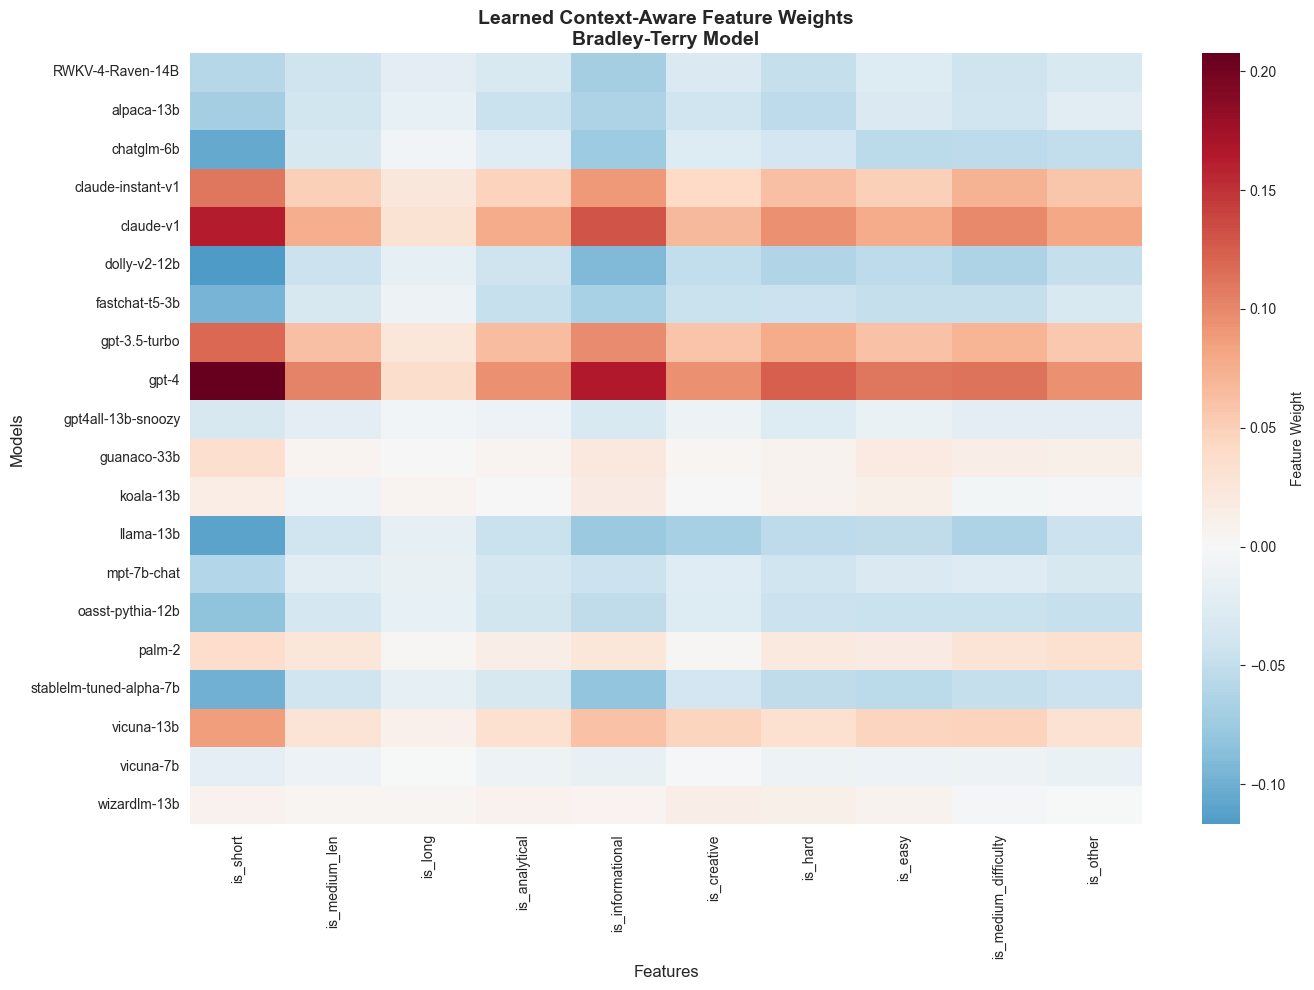

Heatmap created


In [207]:
# Create weight matrix for heatmap
weight_matrix = np.array([context_weights[model] for model in model_names])

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(weight_matrix, 
            xticklabels=feature_cols,
            yticklabels=model_names,
            cmap='RdBu_r',
            center=0,
            ax=ax,
            cbar_kws={'label': 'Feature Weight'})
plt.title('Learned Context-Aware Feature Weights\nBradley-Terry Model', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Models', fontsize=12)
plt.tight_layout()
plt.show()

print("Heatmap created")

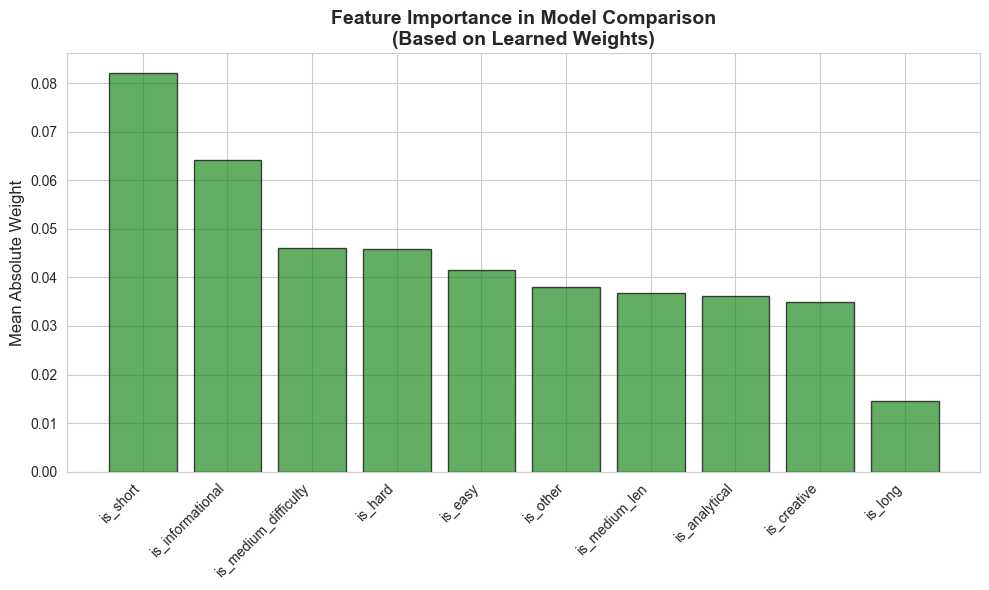

Feature importance chart created


In [208]:
# Feature importance across all models
feature_importance = np.mean(np.abs(weight_matrix), axis=0)
feature_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(feature_imp_df)), feature_imp_df['Importance'], 
               color='forestgreen', edgecolor='black', alpha=0.7)
ax.set_xticks(range(len(feature_imp_df)))
ax.set_xticklabels(feature_imp_df['Feature'], rotation=45, ha='right')
ax.set_ylabel('Mean Absolute Weight', fontsize=12)
ax.set_title('Feature Importance in Model Comparison\n(Based on Learned Weights)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Feature importance chart created")

## 7. Save Trained Weights for Downstream Algorithms

In [209]:
# Prepare weights for JSON export
weights_for_json = {
    model: context_weights[model].tolist() 
    for model in model_names
}

# Create output directory if needed
os.makedirs('data', exist_ok=True)

print("Saving context weights to JSON...")

# Save context weights
output_path_weights = 'data/dueling_context_weights.json'
with open(output_path_weights, 'w') as f:
    json.dump(weights_for_json, f, indent=2)
print(f"Weights saved to {output_path_weights}")

Saving context weights to JSON...
Weights saved to data/dueling_context_weights.json


In [210]:

# Extract and save initialization scores
print("Saving initialization scores to JSON...")

initialization_scores = dueling.get_initialization_scores()

# Convert numpy types to native Python types for JSON serialization
scores_for_json = {
    model: float(score) 
    for model, score in initialization_scores.items()
}

# Save initialization scores
output_path_scores = 'data/dueling_initialization_scores.json'
with open(output_path_scores, 'w') as f:
    json.dump(scores_for_json, f, indent=2)
print(f"Initialization scores saved to {output_path_scores}")



Saving initialization scores to JSON...
Initialization scores saved to data/dueling_initialization_scores.json


In [211]:
# Save comprehensive summary
summary_data = {
    'metadata': {
        'algorithm': 'Dueling Contextual Bandit (Bradley-Terry)',
        'dataset': 'df_bandit.json',
        'timestamp': pd.Timestamp.now().isoformat(),
        'n_models': len(model_names),
        'n_features': len(feature_cols),
        'n_pairs': len(df),
    },
    'training_summary': summary,
    'feature_names': feature_cols,
    'model_names': model_names,
}

output_path_summary = 'data/dueling_training_summary.json'
with open(output_path_summary, 'w') as f:
    json.dump(summary_data, f, indent=2)
print(f"Training summary saved to {output_path_summary}")

Training summary saved to data/dueling_training_summary.json


In [212]:
print("\nDueling Bandit Training Complete\n")

print("Generated files:")
print(f"1. {output_path_scores}")
print(f"   Initialization scores for all models [0-10]")
print(f"2. {output_path_weights}")
print(f"   Context-aware quality weights")
print(f"3. {output_path_summary}")
print(f"   Complete training metadata")


Dueling Bandit Training Complete

Generated files:
1. data/dueling_initialization_scores.json
   Initialization scores for all models [0-10]
2. data/dueling_context_weights.json
   Context-aware quality weights
3. data/dueling_training_summary.json
   Complete training metadata
